In [1]:
import pandas as pd
import SimpleITK as sitk
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
import ast

In [ ]:
df_pre_data = pd.read_csv(r'preprocessing_log.csv')

In [17]:
df_pre_data[df_pre_data['status']=='Failed'].to_csv('failed_preprocessing_temp.csv', index=False)

In [10]:
df_pre_data.dtypes

SeriesInstanceUID    object
status               object
shape_z_y_x          object
error                object
dtype: object

In [26]:
df_pre_data_suc = df_pre_data[df_pre_data['status']=='Success'].copy()

In [19]:
df_pre_data_suc.shape

(1794, 4)

In [20]:
df_pre_data_suc

,SeriesInstanceUID,status,shape_z_y_x,error
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,Success,"(86, 299, 253)",NaN
1,1.2.826.0.1.3680043.8.498.10014757658335054766...,Success,"(163, 297, 234)",NaN
2,1.2.826.0.1.3680043.8.498.10021411248005513321...,Success,"(124, 314, 240)",NaN
3,1.2.826.0.1.3680043.8.498.10022796280698534221...,Success,"(8, 45, 65)",NaN
4,1.2.826.0.1.3680043.8.498.10030095840917973694...,Success,"(106, 174, 240)",NaN
...,...,...,...,...
1852,1.2.826.0.1.3680043.8.498.99887675554378211308...,Success,"(44, 153, 58)",NaN
1853,1.2.826.0.1.3680043.8.498.99892390884723813599...,Success,"(128, 305, 251)",NaN
1854,1.2.826.0.1.3680043.8.498.99895756899933461331...,Success,"(25, 62, 58)",NaN
1855,1.2.826.0.1.3680043.8.498.99953513260518059135...,Success,"(18, 117, 75)",NaN


In [ ]:
df_pre_data_suc['shape_z_y_x'] = df_pre_data_suc['shape_z_y_x'].apply(ast.literal_eval)

In [ ]:
def find_area(x):
    x,y,z= x
    return x*y*z

In [ ]:
df_pre_data_suc['area'] = df_pre_data_suc['shape_z_y_x'].apply(find_area)

<Axes: xlabel='area'>

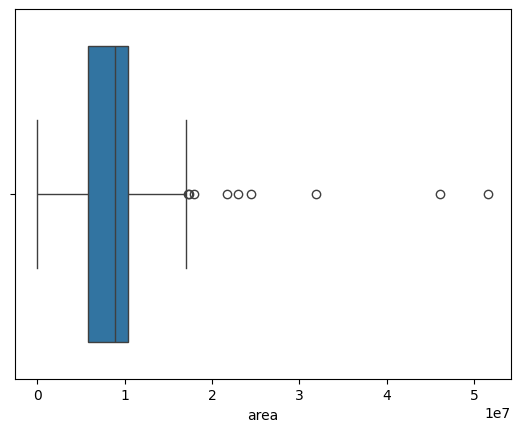

In [45]:
sns.boxplot(x=df_pre_data_suc['area'])

In [5]:
list_of_files = os.listdir(r'processed_data')

In [7]:
train_df = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')

In [9]:
train_df

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10004044428023505108...,64,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1.2.826.0.1.3680043.8.498.10004684224894397679...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.8.498.10005158603912009425...,58,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1.2.826.0.1.3680043.8.498.10009383108068795488...,71,Male,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.2.826.0.1.3680043.8.498.10012790035410518400...,48,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4400,1.2.826.0.1.3680043.8.498.99915610493694667606...,62,Female,MRI T1post,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4401,1.2.826.0.1.3680043.8.498.99920680741054836990...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4402,1.2.826.0.1.3680043.8.498.99953513260518059135...,44,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4403,1.2.826.0.1.3680043.8.498.99982144859397209076...,58,Female,MRI T2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [35]:
prep_df = pd.DataFrame((files[:-7] for files in list_of_files), columns=['SeriesInstanceUID'])
prep_df.iloc[3].values


array(['1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557'],
      dtype=object)

In [36]:
prep_df = prep_df.merge(train_df, how='inner', on='SeriesInstanceUID')
prep_df


,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,58,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,1,1
1,1.2.826.0.1.3680043.8.498.10014757658335054766...,53,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.8.498.10021411248005513321...,55,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1.2.826.0.1.3680043.8.498.10034081836061566510...,54,Male,CTA,0,0,0,0,0,0,1,0,0,0,0,0,0,1
4,1.2.826.0.1.3680043.8.498.10035643165968342618...,62,Female,CTA,0,0,0,1,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,1.2.826.0.1.3680043.8.498.99344977894147397154...,66,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
660,1.2.826.0.1.3680043.8.498.99437700549224405450...,53,Female,CTA,0,0,0,0,0,0,0,1,0,0,0,0,0,1
661,1.2.826.0.1.3680043.8.498.99892390884723813599...,68,Female,CTA,0,0,0,0,1,1,0,0,0,0,0,0,0,1
662,1.2.826.0.1.3680043.8.498.99895756899933461331...,39,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [37]:
list_seg = os.listdir(r'rsna-intracranial-aneurysm-detection\segmentations')

In [38]:
list_seg

['1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381',
 '1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485',
 '1.2.826.0.1.3680043.8.498.10188636688783982623025997809119805350',
 '1.2.826.0.1.3680043.8.498.10410600166004340343973545138447283460',
 '1.2.826.0.1.3680043.8.498.10540586847553109495238524904638776495',
 '1.2.826.0.1.3680043.8.498.10557880026294057874761753231388788828',
 '1.2.826.0.1.3680043.8.498.10759842474698331813589731619457567641',
 '1.2.826.0.1.3680043.8.498.10838261583340080792086755879475952843',
 '1.2.826.0.1.3680043.8.498.10865391592895615633871689438787039175',
 '1.2.826.0.1.3680043.8.498.10929608782694347957516071062422315982',
 '1.2.826.0.1.3680043.8.498.10935907012185032169927418164924236382',
 '1.2.826.0.1.3680043.8.498.11140496970152788589837488009637704168',
 '1.2.826.0.1.3680043.8.498.11163718560814217911019576488539324434',
 '1.2.826.0.1.3680043.8.498.11365717786702723641614356829695498020',
 '1.2.826.0.1.3680043.8.498.114229

In [52]:
from view3d_data import *
from preprocess_ct import *

In [55]:
seg_mask = sitk.ReadImage(str(r'rsna-intracranial-aneurysm-detection\segmentations\1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485\1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485.nii'))

In [56]:
seg_mask_np = sitk.GetArrayFromImage(seg_mask)
seg_mask_np.shape

(136, 1024, 1024)

In [57]:
view_3d_volume(seg_mask_np)

interactive(children=(IntSlider(value=68, description='slice_index', max=135), FloatSlider(value=0.0, descript…

In [54]:
import numpy as np

print("Unique values in mask:", np.unique(seg_mask_np))
print("Number of aneurysm voxels:", np.sum(seg_mask_np > 0))


Unique values in mask: [-1024. -1023. -1022. ...  2680.  2686.  2692.]
Number of aneurysm voxels: 13658632


In [50]:
train_df[train_df['SeriesInstanceUID']=='1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381']

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
13,1.2.826.0.1.3680043.8.498.10035643165968342618...,62,Female,CTA,0,0,0,1,1,0,0,0,1,0,0,0,0,1


In [58]:
local_df = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train_localizers.csv')
local_df

,SeriesInstanceUID,SOPInstanceUID,coordinates,location
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,1.2.826.0.1.3680043.8.498.10775329348174902199...,"{'x': 258.3621186176837, 'y': 261.359900373599}",Other Posterior Circulation
1,1.2.826.0.1.3680043.8.498.10022796280698534221...,1.2.826.0.1.3680043.8.498.53868409774237283281...,"{'x': 194.87253141831238, 'y': 178.32675044883...",Right Middle Cerebral Artery
2,1.2.826.0.1.3680043.8.498.10023411164590664678...,1.2.826.0.1.3680043.8.498.24186535344744886473...,"{'x': 189.23979878597123, 'y': 209.19184886465...",Right Middle Cerebral Artery
3,1.2.826.0.1.3680043.8.498.10030095840917973694...,1.2.826.0.1.3680043.8.498.75217084841854214544...,"{'x': 208.2805049088359, 'y': 229.78962131837307}",Right Infraclinoid Internal Carotid Artery
4,1.2.826.0.1.3680043.8.498.10034081836061566510...,1.2.826.0.1.3680043.8.498.71237104731452368587...,"{'x': 249.86745590416498, 'y': 220.623044646393}",Anterior Communicating Artery
...,...,...,...,...
2281,1.2.826.0.1.3680043.8.498.99892390884723813599...,1.2.826.0.1.3680043.8.498.12398549862508001109...,"{'x': 139.11888111888112, 'y': 283.97202797202...",Right Middle Cerebral Artery
2282,1.2.826.0.1.3680043.8.498.99892390884723813599...,1.2.826.0.1.3680043.8.498.12398549862508001109...,"{'x': 63.132075471698116, 'y': 195.8238993710692}",Left Middle Cerebral Artery
2283,1.2.826.0.1.3680043.8.498.99892390884723813599...,1.2.826.0.1.3680043.8.498.21598979799967012280...,"{'x': 14.510769230769231, 'y': 247.53230769230...",Right Middle Cerebral Artery
2284,1.2.826.0.1.3680043.8.498.99892390884723813599...,1.2.826.0.1.3680043.8.498.21598979799967012280...,"{'x': 167.3230769230769, 'y': 265.64923076923077}",Left Middle Cerebral Artery
